In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/metro_interstate_traffic_volume_clean.csv", parse_dates=['date_time'])
df.shape

(40575, 8)

In [2]:
df['hour']=df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.day_name()
df[['date_time', 'hour', 'day_of_week']].head()

,date_time,hour,day_of_week
0,2012-10-02 09:00:00,9,Tuesday
1,2012-10-02 10:00:00,10,Tuesday
2,2012-10-02 11:00:00,11,Tuesday
3,2012-10-02 12:00:00,12,Tuesday
4,2012-10-02 13:00:00,13,Tuesday


In [3]:
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)
df['is_weekend'].value_counts()

is_weekend
0    28979
1    11596
Name: count, dtype: int64

In [4]:
df['is_holiday'] = df['holiday'].notna().astype(int)
df['is_holiday'].value_counts()

is_holiday
0    40522
1       53
Name: count, dtype: int64

In [8]:
peak_hours = [6, 7, 8, 14, 15, 16, 17]
df['is_peak_hour'] = (df['hour'].isin(peak_hours) & (df['is_weekend'] == 0)).astype(int)
df['is_peak_hour'].value_counts()

is_peak_hour
0    32172
1     8403
Name: count, dtype: int64

In [9]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df[['hour', 'hour_sin', 'hour_cos']].head()

,hour,hour_sin,hour_cos
0,9,7.071068e-01,-0.707107
1,10,5.000000e-01,-0.866025
2,11,2.588190e-01,-0.965926
3,12,1.224647e-16,-1.000000
4,13,-2.588190e-01,-0.965926


In [ ]:
weather_counts = df['weather_main'].value_counts()
print(weather_counts)

weather_main
Clouds          15120
Clear           13369
Rain             4367
Mist             3230
Snow             2162
Haze              830
Drizzle           685
Thunderstorm      485
Fog               312
Smoke              13
Squall              2
Name: count, dtype: int64

In [13]:
rare_weather = weather_counts[weather_counts < 100].index.tolist()
print("Grouping into 'Other':", rare_weather)

df['weather_main_grouped'] = df['weather_main'].apply(lambda x: 'Other' if x in rare_weather else x)
df['weather_main_grouped'].value_counts()

Grouping into 'Other': ['Smoke', 'Squall']


weather_main_grouped
Clouds          15120
Clear           13369
Rain             4367
Mist             3230
Snow             2162
Haze              830
Drizzle           685
Thunderstorm      485
Fog               312
Other              15
Name: count, dtype: int64

In [14]:
df['congestion_level'] = pd.qcut(df['traffic_volume'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
df['congestion_level'].value_counts()

congestion_level
High         10145
Low          10144
Medium       10144
Very High    10142
Name: count, dtype: int64

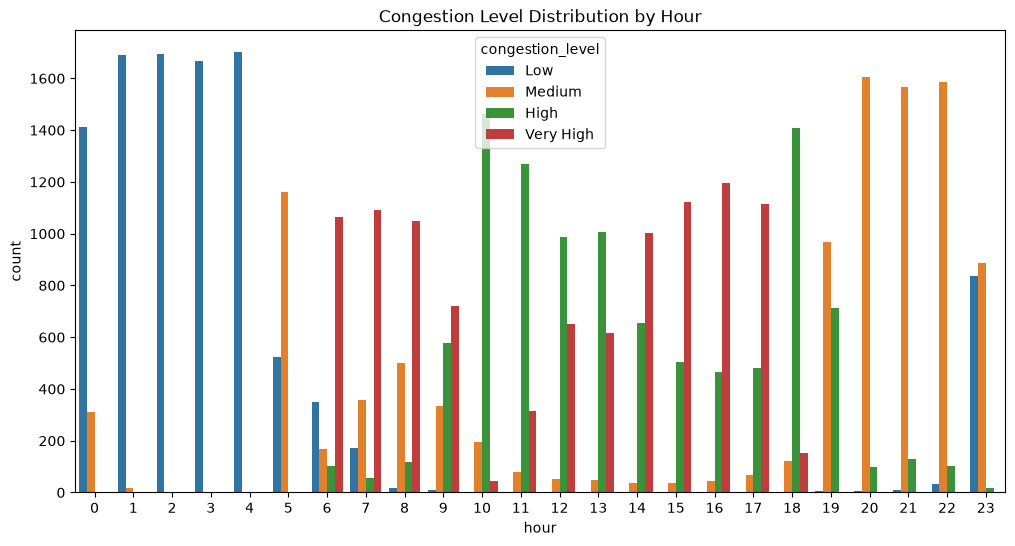

In [15]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='hour', hue='congestion_level')
plt.title('Congestion Level Distribution by Hour')
plt.show()

In [16]:
df = df.drop(columns=['holiday', 'weather_main'])
df.columns.tolist()

['temp',
 'rain_1h',
 'snow_1h',
 'clouds_all',
 'date_time',
 'traffic_volume',
 'hour',
 'day_of_week',
 'is_weekend',
 'is_holiday',
 'is_peak_hour',
 'hour_sin',
 'hour_cos',
 'weather_main_grouped',
 'congestion_level']

In [17]:
df.to_csv('../data/processed/traffic_features.csv', index=False)
print("Saved:", df.shape)
df.head()

Saved: (40575, 15)


,temp,rain_1h,snow_1h,clouds_all,date_time,traffic_volume,hour,day_of_week,is_weekend,is_holiday,is_peak_hour,hour_sin,hour_cos,weather_main_grouped,congestion_level
0,288.28,0.0,0.0,40,2012-10-02 09:00:00,5545,9,Tuesday,0,0,0,7.071068e-01,-0.707107,Clouds,Very High
1,289.36,0.0,0.0,75,2012-10-02 10:00:00,4516,10,Tuesday,0,0,0,5.000000e-01,-0.866025,Clouds,High
2,289.58,0.0,0.0,90,2012-10-02 11:00:00,4767,11,Tuesday,0,0,0,2.588190e-01,-0.965926,Clouds,High
3,290.13,0.0,0.0,90,2012-10-02 12:00:00,5026,12,Tuesday,0,0,0,1.224647e-16,-1.000000,Clouds,Very High
4,291.14,0.0,0.0,75,2012-10-02 13:00:00,4918,13,Tuesday,0,0,0,-2.588190e-01,-0.965926,Clouds,High
